# Highlight Sentiment Classifier

Predict `highlight_sentiment` (1–7 sentiment rating, where **1 = negative/inappropriate** and **7 = positive/appropriate**) for each text selection using structured features only: response strategy codes, scenario/prompt factors, and parent demographics. No raw text is used.

Three target framings are evaluated:
- **Binary**: positive sentiment (≥5) vs. negative/neutral (<5)
- **3-bin ordinal**: negative (1–3) / neutral (4–5) / positive (6–7)
- **7-class ordinal**: each rating 1–7 as a separate class

`concern_level` and `realism_level` are excluded — they are parent session judgments that would leak the target.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_validate, train_test_split,
)
from sklearn.metrics import (
    f1_score, roc_auc_score, make_scorer, mean_absolute_error,
    confusion_matrix, ConfusionMatrixDisplay,
)
import mord
import lightgbm as lgb

DATA_DIR = Path('../data-exports/20260412_183830/highlight_analysis_output')
OUT_DIR  = DATA_DIR / 'classifier_output'
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
OUTER_K      = 5


## Load data

In [2]:
df = pd.read_csv(DATA_DIR / 'df_sel.csv')
print(f"Shape: {df.shape}")

print("\nhighlight_sentiment distribution:")
vc = df['highlight_sentiment'].value_counts().sort_index()
print(vc)
print(f"\nMean:   {df['highlight_sentiment'].mean():.2f}")
print(f"Median: {df['highlight_sentiment'].median():.2f}")
print(f"\nmodel_strategy nulls: {df['model_strategy'].isna().sum()}  "
      "(non-response highlights — not Unknown, genuinely missing)")


Shape: (200, 49)

highlight_sentiment distribution:
highlight_sentiment
1    10
2    18
3    10
4    25
5    16
6    37
7    84
Name: count, dtype: int64

Mean:   5.33
Median: 6.00

model_strategy nulls: 16  (non-response highlights — not Unknown, genuinely missing)


## Target distributions

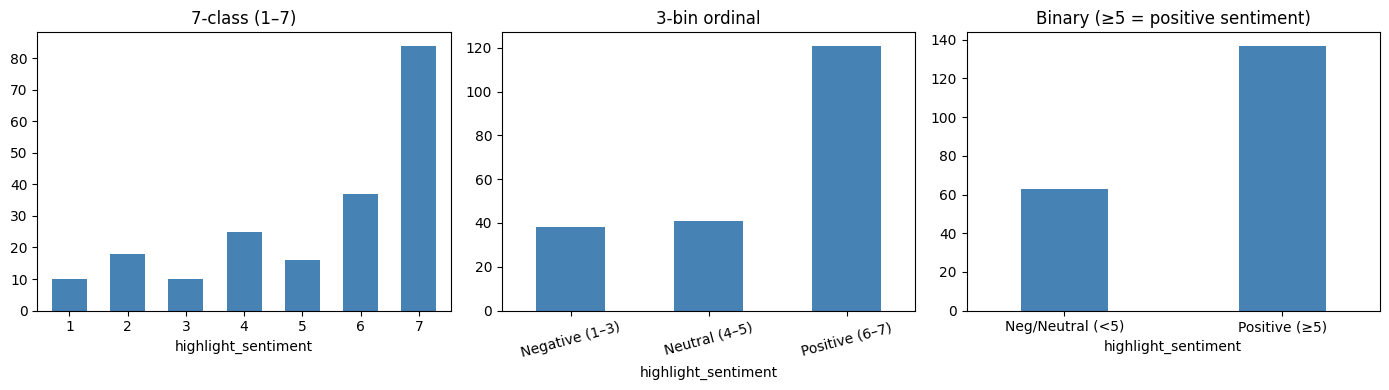

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

vc.plot.bar(ax=axes[0], color='steelblue', width=0.6)
axes[0].set_title('7-class (1–7)')
axes[0].set_xlabel('highlight_sentiment')
axes[0].tick_params(axis='x', rotation=0)

y3_labels = pd.cut(df['highlight_sentiment'], bins=[0,3.5,5.5,7.5],
                   labels=['Negative (1–3)', 'Neutral (4–5)', 'Positive (6–7)'])
y3_labels.value_counts().sort_index().plot.bar(ax=axes[1], color='steelblue', width=0.5)
axes[1].set_title('3-bin ordinal')
axes[1].tick_params(axis='x', rotation=15)

yb_labels = pd.cut(df['highlight_sentiment'], bins=[0,4.5,7.5],
                   labels=['Neg/Neutral (<5)', 'Positive (≥5)'])
yb_labels.value_counts().sort_index().plot.bar(ax=axes[2], color='steelblue', width=0.4)
axes[2].set_title('Binary (≥5 = positive sentiment)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(OUT_DIR / 'target_distributions.png', dpi=100)
plt.show()


## Feature engineering

### Feature groups
- **A** — Response strategy: `model_strategy` (one-hot + null indicator), `parent_motivation` (one-hot)
- **B** — Scenario/prompt: domain, age band, sensitivity, relationship frame, space type, trait, breakdown
- **C** — Parent demographics: gender, age, education, GenAI familiarity/usage, parenting style, child AI use, etc.

**`model_strategy` NaN**: these 16 rows are highlights of non-response text (e.g., the child's prompt). They are genuinely missing, not Unknown. We add a `strategy_is_null` indicator and fill NaN with `'none'` so one-hot encoding produces a `strat_none` column that is distinct from any real strategy.

In [4]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)

    # ── Group A: Response strategy ────────────────────────────────────────────
    out['strategy_is_null'] = df['model_strategy'].isna().astype(int)
    strat_dummies = pd.get_dummies(df['model_strategy'].fillna('none'), prefix='strat')
    out = pd.concat([out, strat_dummies], axis=1)

    motiv_dummies = pd.get_dummies(df['parent_motivation'].fillna('unknown'), prefix='motiv')
    out = pd.concat([out, motiv_dummies], axis=1)

    # ── Group B: Scenario/prompt factors ─────────────────────────────────────
    for col in ['domain', 'age_band', 'sensitivity_level', 'relationship_frame',
                'space_type', 'trait', 'trait_level']:
        dummies = pd.get_dummies(df[col].fillna('unknown'), prefix=col)
        out = pd.concat([out, dummies], axis=1)

    out['breakdown_expected'] = (df['breakdown_expected'] == 'yes').astype(int)

    # ── Group C: Parent demographics ─────────────────────────────────────────
    for col in ['parent_gender', 'parent_age_group', 'parent_education',
                'parent_ethnicity', 'area_of_residency',
                'child_has_ai_use', 'parent_llm_monitoring_level']:
        dummies = pd.get_dummies(df[col].fillna('unknown'), prefix=col)
        out = pd.concat([out, dummies], axis=1)

    # genai_familiarity: binary
    out['genai_regular_user'] = (df['genai_familiarity'] == 'regular_user').astype(int)

    # genai_usage_frequency: ordinal
    freq_map = {'daily': 2, 'weekly': 1, 'monthly_or_less': 0}
    out['genai_usage_freq'] = df['genai_usage_frequency'].map(freq_map).fillna(0).astype(int)

    # parent_internet_use_frequency: kept as-is (numeric)
    out['parent_internet_use_frequency'] = pd.to_numeric(
        df['parent_internet_use_frequency'], errors='coerce').fillna(0)

    # is_only_child: binary
    out['is_only_child'] = (df['is_only_child'].astype(str).str.lower() == 'yes').astype(int)

    # parenting_style: multi-hot (values like "A;C", "A;B;D")
    for style in list('ABCD'):
        out[f'parenting_{style}'] = (
            df['parenting_style'].fillna('').str.contains(style).astype(int)
        )

    return out.astype(float)


X_all = build_features(df)
print(f"X_all shape: {X_all.shape}")

A_COLS = [c for c in X_all.columns
          if c.startswith(('strategy_is_null', 'strat_', 'motiv_'))]
B_COLS = [c for c in X_all.columns
          if c.startswith(('domain_', 'age_band_', 'sensitivity_level_',
                           'relationship_frame_', 'space_type_', 'trait_',
                           'breakdown_expected'))]
C_COLS = [c for c in X_all.columns if c not in A_COLS + B_COLS]

print(f"Group A: {len(A_COLS)} features")
print(f"Group B: {len(B_COLS)} features")
print(f"Group C: {len(C_COLS)} features")
print(f"All columns: {list(X_all.columns)}")


X_all shape: (200, 80)
Group A: 22 features
Group B: 22 features
Group C: 36 features
All columns: ['strategy_is_null', 'strat_Adapt to Age Group', "strat_Clarify Child's Intent", 'strat_Defer to Resources', 'strat_Emphasize Emotional Support', 'strat_Emphasize Risk Awareness', 'strat_Encourage Introspection', 'strat_Explain Problems in Prompt', 'strat_Prompted Suggestions', 'strat_Redirect with Alternatives', 'strat_Refuse Response and Explain', 'strat_Unprompted Suggestions', 'strat_none', 'motiv_Child Intentions', 'motiv_Parents Trust of Model Capabilities', 'motiv_Response Complexity', 'motiv_Response Contradicts Itself', 'motiv_Response Could Evoke Strong Emotion', 'motiv_Response Identification of the Root Cause', 'motiv_Response Organization', 'motiv_Response Risk Awareness', 'motiv_Response Usefulness', 'domain_Academic Domain', 'domain_Casual Knowledge Domain', 'domain_Relationship Domain', 'age_band_13-15', 'age_band_16-18', 'age_band_6-8', 'age_band_9-12', 'sensitivity_level

## Target arrays

In [5]:
y_binary = (df['highlight_sentiment'] >= 5).astype(int).values
y_3bin   = pd.cut(df['highlight_sentiment'], bins=[0, 3.5, 5.5, 7.5],
                  labels=[0, 1, 2]).astype(int).values
y_7class = (df['highlight_sentiment'].astype(int) - 1).values  # 0-indexed (0–6)

print("Binary (0=neg/neutral <5, 1=positive ≥5):", np.bincount(y_binary))
print("3-bin (0=negative 1–3, 1=neutral 4–5, 2=positive 6–7):", np.bincount(y_3bin))
print("7-class distribution (0=rating1 … 6=rating7):", np.bincount(y_7class))


Binary (0=neg/neutral <5, 1=positive ≥5): [ 63 137]
3-bin (0=negative 1–3, 1=neutral 4–5, 2=positive 6–7): [ 38  41 121]
7-class distribution (0=rating1 … 6=rating7): [10 18 10 25 16 37 84]


## Cross-validation helpers

**Design**: stratified 5-fold outer CV. For the 7-class task, classes 1 and 3 (N=10 each) may produce folds with < 2 samples; we fall back to unstratified KFold automatically.

In [6]:
def safe_cv(y, k=5, random_state=42):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    try:
        list(skf.split(np.zeros(len(y)), y))   # dry-run; raises if a fold is empty
        return skf
    except ValueError:
        return KFold(n_splits=k, shuffle=True, random_state=random_state)


def run_cv(X, y, models: dict, task: str, k: int = OUTER_K) -> pd.DataFrame:
    """Evaluate each model with k-fold CV. Returns tidy results DataFrame."""
    cv = safe_cv(y, k=k)

    if task == 'binary':
        scoring = {'f1': 'f1', 'roc_auc': 'roc_auc', 'accuracy': 'accuracy'}
    else:
        scoring = {
            'f1_weighted': 'f1_weighted',
            'neg_mae': make_scorer(mean_absolute_error, greater_is_better=False),
        }

    rows = []
    for name, model in models.items():
        try:
            scores = cross_validate(model, X, y, cv=cv, scoring=scoring,
                                    error_score='raise', n_jobs=-1)
            row = {'model': name}
            for k_score, v in scores.items():
                if k_score.startswith('test_'):
                    metric = k_score[5:]
                    row[f'{metric}_mean'] = np.mean(v)
                    row[f'{metric}_std']  = np.std(v)
            rows.append(row)
        except Exception as exc:
            rows.append({'model': name, 'error': str(exc)})

    return pd.DataFrame(rows)


## Model definitions

In [7]:
def models_binary():
    return {
        'Majority Baseline':    DummyClassifier(strategy='most_frequent'),
        'Stratified Baseline':  DummyClassifier(strategy='stratified',
                                                random_state=RANDOM_STATE),
        'Logistic Regression':  LogisticRegression(max_iter=1000, C=1.0,
                                                   random_state=RANDOM_STATE),
        'Naive Bayes':          BernoulliNB(),
        'Decision Tree':        DecisionTreeClassifier(max_depth=5,
                                                       random_state=RANDOM_STATE),
        'Random Forest':        RandomForestClassifier(n_estimators=300, max_depth=8,
                                                       random_state=RANDOM_STATE),
        'LightGBM':             lgb.LGBMClassifier(n_estimators=100, max_depth=5,
                                                   num_leaves=15, verbose=-1,
                                                   random_state=RANDOM_STATE),
        'SVM (linear)':         LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
    }


def models_multiclass():
    return {
        'Majority Baseline':    DummyClassifier(strategy='most_frequent'),
        'Stratified Baseline':  DummyClassifier(strategy='stratified',
                                                random_state=RANDOM_STATE),
        'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'Ordinal LogReg (mord)': mord.LogisticAT(alpha=1.0),
        'Naive Bayes':           BernoulliNB(),
        'Decision Tree':         DecisionTreeClassifier(max_depth=5,
                                                        random_state=RANDOM_STATE),
        'Random Forest':         RandomForestClassifier(n_estimators=300, max_depth=8,
                                                        random_state=RANDOM_STATE),
        'LightGBM':              lgb.LGBMClassifier(n_estimators=100, max_depth=5,
                                                    num_leaves=15, verbose=-1,
                                                    random_state=RANDOM_STATE),
    }


## Task 1 — Binary classification (positive sentiment ≥5 vs. negative/neutral <5)

In [8]:
print("Positive class rate (≥5):", y_binary.mean().round(3))

res_binary = run_cv(X_all.values, y_binary, models_binary(), task='binary')
cols_show  = [c for c in ['model', 'f1_mean', 'f1_std',
                           'roc_auc_mean', 'roc_auc_std', 'accuracy_mean', 'error']
              if c in res_binary.columns]
print(res_binary[cols_show].to_string(index=False))
res_binary.to_csv(OUT_DIR / 'cv_binary.csv', index=False)


Positive class rate (≥5): 0.685
              model  f1_mean   f1_std  roc_auc_mean  roc_auc_std  accuracy_mean
  Majority Baseline 0.812994 0.008602      0.500000     0.000000          0.685
Stratified Baseline 0.708772 0.034379      0.496724     0.056539          0.585
Logistic Regression 0.865230 0.030540      0.857830     0.055656          0.810
        Naive Bayes 0.796906 0.054119      0.807682     0.060829          0.735
      Decision Tree 0.850145 0.042762      0.803699     0.056580          0.790
      Random Forest 0.859967 0.046084      0.876063     0.030861          0.805
           LightGBM 0.839260 0.020506      0.844053     0.010181          0.775
       SVM (linear) 0.866568 0.042757      0.857224     0.071114          0.815


## Task 2 — 3-bin ordinal (low / mid / high)

In [9]:
res_3bin = run_cv(X_all.values, y_3bin, models_multiclass(), task='multiclass')
cols_show = [c for c in ['model', 'f1_weighted_mean', 'f1_weighted_std',
                          'neg_mae_mean', 'neg_mae_std', 'error']
             if c in res_3bin.columns]
print(res_3bin[cols_show].to_string(index=False))
res_3bin.to_csv(OUT_DIR / 'cv_3bin.csv', index=False)


                model  f1_weighted_mean  f1_weighted_std  neg_mae_mean  neg_mae_std
    Majority Baseline          0.456154         0.012308        -0.585     0.020000
  Stratified Baseline          0.456180         0.052371        -0.780     0.064031
  Logistic Regression          0.830985         0.033763        -0.240     0.066332
Ordinal LogReg (mord)          0.727542         0.038930        -0.325     0.057009
          Naive Bayes          0.691354         0.026748        -0.465     0.040620
        Decision Tree          0.720978         0.042247        -0.330     0.073144
        Random Forest          0.809506         0.050885        -0.245     0.076485
             LightGBM          0.802376         0.049956        -0.280     0.091378


## Task 3 — 7-class ordinal (ratings 1–7)

Sparse at the low end (classes 0–2 have 10–18 samples each). Uses unstratified KFold if stratification fails.

In [10]:
res_7class = run_cv(X_all.values, y_7class, models_multiclass(), task='multiclass')
cols_show = [c for c in ['model', 'f1_weighted_mean', 'f1_weighted_std',
                          'neg_mae_mean', 'neg_mae_std', 'error']
             if c in res_7class.columns]
print(res_7class[cols_show].to_string(index=False))
res_7class.to_csv(OUT_DIR / 'cv_7class.csv', index=False)


                model  f1_weighted_mean  f1_weighted_std  neg_mae_mean  neg_mae_std
    Majority Baseline          0.248521         0.009975        -1.670     0.060000
  Stratified Baseline          0.259137         0.046139        -1.945     0.097980
  Logistic Regression          0.600102         0.049262        -0.850     0.129422
Ordinal LogReg (mord)          0.486838         0.033528        -0.915     0.112472
          Naive Bayes          0.571074         0.082548        -1.105     0.315991
        Decision Tree          0.523941         0.038223        -1.040     0.087464
        Random Forest          0.576840         0.044066        -0.820     0.158430
             LightGBM          0.544688         0.050221        -0.895     0.104163


## Ablation — feature group contribution

Run Random Forest (binary task) with three feature subsets to measure how much each group adds.

In [11]:
rf_abl = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)
cv_abl = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ablation_rows = []
for label, cols in [('A only',  A_COLS),
                    ('A + B',   A_COLS + B_COLS),
                    ('A + B + C', A_COLS + B_COLS + C_COLS)]:
    X_sub  = X_all[cols].values
    scores = cross_validate(rf_abl, X_sub, y_binary, cv=cv_abl,
                            scoring={'f1': 'f1', 'roc_auc': 'roc_auc'})
    ablation_rows.append({
        'feature set': label,
        'n_features':  len(cols),
        'F1 (mean)':   scores['test_f1'].mean(),
        'F1 (std)':    scores['test_f1'].std(),
        'AUC (mean)':  scores['test_roc_auc'].mean(),
        'AUC (std)':   scores['test_roc_auc'].std(),
    })

abl_df = pd.DataFrame(ablation_rows)
print(abl_df.to_string(index=False))
abl_df.to_csv(OUT_DIR / 'ablation_rf_binary.csv', index=False)


feature set  n_features  F1 (mean)  F1 (std)  AUC (mean)  AUC (std)
     A only          22   0.866076  0.043117    0.820230   0.072602
      A + B          44   0.831221  0.041034    0.826333   0.073759
  A + B + C          80   0.859967  0.046084    0.876063   0.030861


## Feature importance

Fit Random Forest and LightGBM on the full dataset (all features, binary target) and plot top-20 feature importances.

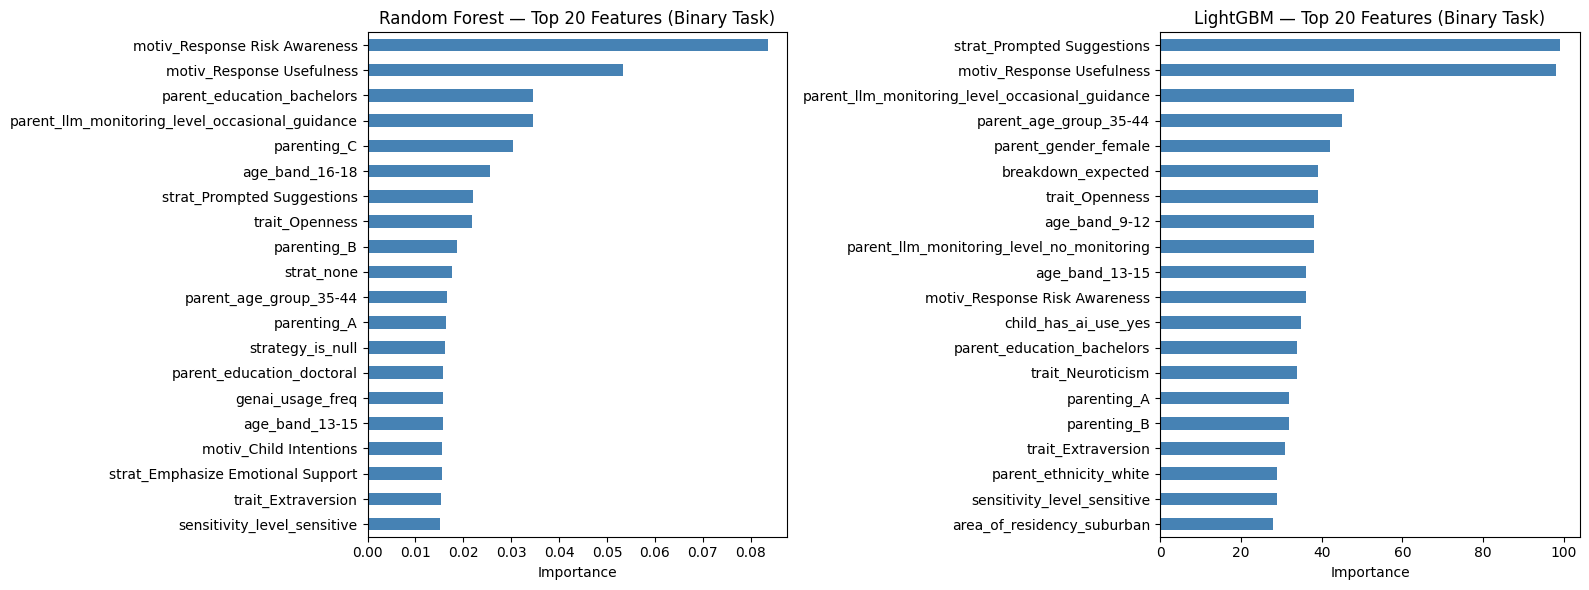


Top 10 RF:
motiv_Response Risk Awareness                      0.083496
motiv_Response Usefulness                          0.053396
parent_education_bachelors                         0.034637
parent_llm_monitoring_level_occasional_guidance    0.034555
parenting_C                                        0.030267
age_band_16-18                                     0.025523
strat_Prompted Suggestions                         0.022071
trait_Openness                                     0.021844
parenting_B                                        0.018741
strat_none                                         0.017631

Top 10 LightGBM:
strat_Prompted Suggestions                         99
motiv_Response Usefulness                          98
parent_llm_monitoring_level_occasional_guidance    48
parent_age_group_35-44                             45
parent_gender_female                               42
breakdown_expected                                 39
trait_Openness                                

In [12]:
rf_full = RandomForestClassifier(n_estimators=500, max_depth=8, random_state=RANDOM_STATE)
rf_full.fit(X_all.values, y_binary)
rf_imp = pd.Series(rf_full.feature_importances_, index=X_all.columns).sort_values(ascending=False)

lgb_full = lgb.LGBMClassifier(n_estimators=200, max_depth=5, num_leaves=15,
                               verbose=-1, random_state=RANDOM_STATE)
lgb_full.fit(X_all.values, y_binary)
lgb_imp = pd.Series(lgb_full.feature_importances_, index=X_all.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, imp, title in [(axes[0], rf_imp, 'Random Forest'),
                       (axes[1], lgb_imp, 'LightGBM')]:
    imp.head(20).sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_title(f'{title} — Top 20 Features (Binary Task)')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance.png', dpi=100)
plt.show()

print("\nTop 10 RF:")
print(rf_imp.head(10).to_string())
print("\nTop 10 LightGBM:")
print(lgb_imp.head(10).to_string())


## Confusion matrices

Fixed 80/20 train-test split for a single readable confusion matrix per task.

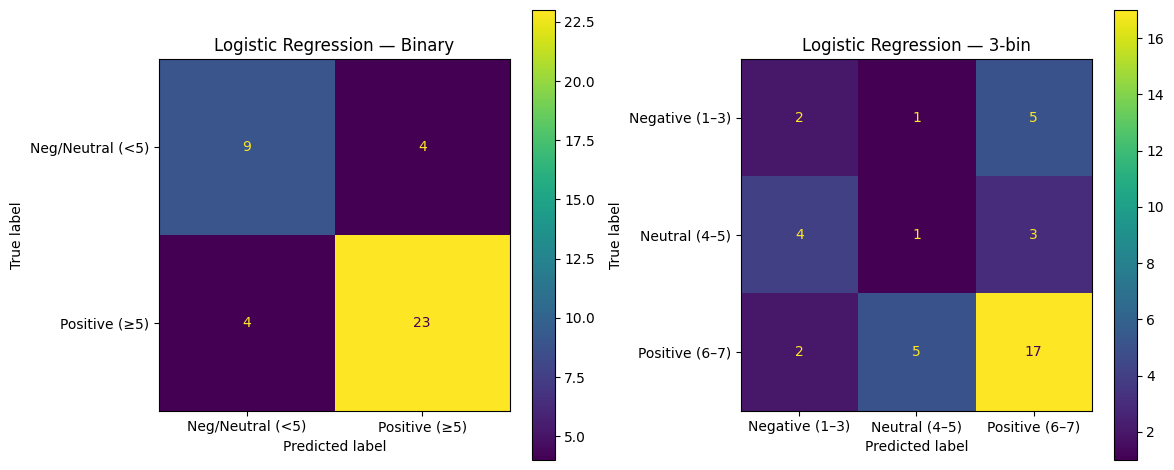

In [13]:
X_tr, X_te, yb_tr, yb_te = train_test_split(
    X_all.values, y_binary, test_size=0.2, stratify=y_binary,
    random_state=RANDOM_STATE)
_, _, y3_tr, y3_te = train_test_split(
    X_all.values, y_3bin, test_size=0.2, stratify=y_3bin,
    random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Binary — Logistic Regression
lr_b = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_b.fit(X_tr, yb_tr)
ConfusionMatrixDisplay.from_estimator(
    lr_b, X_te, yb_te, display_labels=['Neg/Neutral (<5)', 'Positive (≥5)'], ax=axes[0])
axes[0].set_title('Logistic Regression — Binary')

# 3-bin — Logistic Regression
lr_3 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_3.fit(X_tr, y3_tr)
ConfusionMatrixDisplay.from_estimator(
    lr_3, X_te, y3_te,
    display_labels=['Negative (1–3)', 'Neutral (4–5)', 'Positive (6–7)'], ax=axes[1])
axes[1].set_title('Logistic Regression — 3-bin')

plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrices.png', dpi=100)
plt.show()


## Logistic Regression coefficients (binary)

Coefficients are interpretable: positive coefficient = pushes toward positive sentiment (≥5); negative coefficient = pushes toward negative/neutral sentiment (<5).

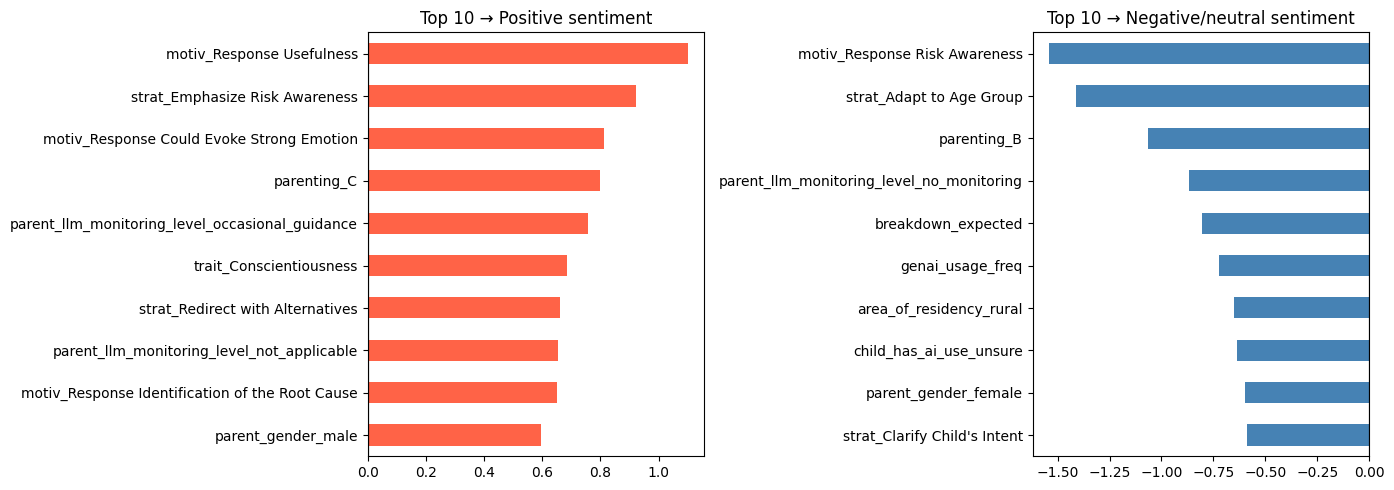

In [14]:
lr_full = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr_full.fit(X_all.values, y_binary)

coef = pd.Series(lr_full.coef_[0], index=X_all.columns)
top_pos = coef.sort_values(ascending=False).head(10)
top_neg = coef.sort_values().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_pos.sort_values().plot.barh(ax=axes[0], color='tomato')
axes[0].set_title('Top 10 → Positive sentiment')
axes[0].axvline(0, color='black', linewidth=0.8)

top_neg.sort_values(ascending=False).plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 → Negative/neutral sentiment')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'lr_coefficients.png', dpi=100)
plt.show()


## A-priori classifier: strategy + scenario + demographics, no motivation

`parent_motivation` is outcome-derived — it reflects what a specific parent chose to attend to,
and cannot be known before a highlight is observed. The classifiers above include it as a feature,
which inflates performance estimates for any deployment scenario where the motivation is not
yet coded.

This section re-runs all three tasks using only features that are knowable a priori:
- **Strategy** (`strat_*`) — what the AI was doing in the response
- **Scenario/prompt** (Group B) — domain, age band, sensitivity, etc.
- **Parent demographics** (Group C) — gender, education, GenAI familiarity, etc.

The gap between the full-model AUC/F1 and the no-motivation AUC/F1 is the outcome-contingent
contribution of motivation — consistent with the motivation gap from the mixed-effects analysis.

In [ ]:
# Feature set: strategy + scenario + demographics, motivation excluded
STRAT_COLS  = [c for c in X_all.columns if c.startswith(('strategy_is_null', 'strat_'))]
APRIORI_COLS = STRAT_COLS + B_COLS + C_COLS

print(f'A-priori feature set: {len(APRIORI_COLS)} features  '
      f'({len(STRAT_COLS)} strategy + {len(B_COLS)} scenario + {len(C_COLS)} demo)')
print(f'Full feature set:     {len(X_all.columns)} features  '
      f'(adds {len([c for c in A_COLS if c.startswith("motiv_")])} motivation dummies)')

X_ap = X_all[APRIORI_COLS].values

# ── Binary ────────────────────────────────────────────────────────────────────
res_ap_binary = run_cv(X_ap, y_binary, models_binary(), task='binary')
res_ap_binary['feature_set'] = 'no_motivation'

res_full_binary = res_binary.copy()
res_full_binary['feature_set'] = 'full (with motivation)'

cmp_binary = pd.concat([res_full_binary, res_ap_binary], ignore_index=True)
cols_b = [c for c in ['model', 'feature_set', 'f1_mean', 'f1_std',
                       'roc_auc_mean', 'roc_auc_std', 'accuracy_mean'] if c in cmp_binary.columns]
print('\n── Binary task ──')
print(cmp_binary[cols_b].sort_values(['model', 'feature_set']).to_string(index=False))
cmp_binary.to_csv(OUT_DIR / 'cv_binary_apriori.csv', index=False)

# ── 3-bin ─────────────────────────────────────────────────────────────────────
res_ap_3bin = run_cv(X_ap, y_3bin, models_multiclass(), task='multiclass')
res_ap_3bin['feature_set'] = 'no_motivation'

res_full_3bin = res_3bin.copy()
res_full_3bin['feature_set'] = 'full (with motivation)'

cmp_3bin = pd.concat([res_full_3bin, res_ap_3bin], ignore_index=True)
cols_3 = [c for c in ['model', 'feature_set', 'f1_weighted_mean', 'f1_weighted_std',
                       'neg_mae_mean'] if c in cmp_3bin.columns]
print('\n── 3-bin task ──')
print(cmp_3bin[cols_3].sort_values(['model', 'feature_set']).to_string(index=False))
cmp_3bin.to_csv(OUT_DIR / 'cv_3bin_apriori.csv', index=False)

# ── 7-class ───────────────────────────────────────────────────────────────────
res_ap_7class = run_cv(X_ap, y_7class, models_multiclass(), task='multiclass')
res_ap_7class['feature_set'] = 'no_motivation'

res_full_7class = res_7class.copy()
res_full_7class['feature_set'] = 'full (with motivation)'

cmp_7class = pd.concat([res_full_7class, res_ap_7class], ignore_index=True)
print('\n── 7-class task ──')
print(cmp_7class[cols_3].sort_values(['model', 'feature_set']).to_string(index=False))
cmp_7class.to_csv(OUT_DIR / 'cv_7class_apriori.csv', index=False)

# ── Delta summary (best model per task) ───────────────────────────────────────
print('\n── Motivation contribution (full − no_motivation, best model per task) ──')
for task_label, cmp, metric in [
    ('Binary    AUC', cmp_binary,  'roc_auc_mean'),
    ('Binary    F1',  cmp_binary,  'f1_mean'),
    ('3-bin     F1',  cmp_3bin,    'f1_weighted_mean'),
    ('7-class   F1',  cmp_7class,  'f1_weighted_mean'),
]:
    if metric not in cmp.columns:
        continue
    full_best = cmp[cmp['feature_set'] == 'full (with motivation)'][metric].max()
    ap_best   = cmp[cmp['feature_set'] == 'no_motivation'][metric].max()
    print(f'  {task_label}: full={full_best:.3f}  no-motiv={ap_best:.3f}  Δ={full_best-ap_best:+.3f}')